In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from modules.MyQComponent import *
import qiskit_metal as metal
from qiskit_metal import designs, draw
from qiskit_metal import MetalGUI, Dict, open_docs
from qiskit_metal.qlibrary.terminations.launchpad_wb_driven import LaunchpadWirebondDriven

import matplotlib.pyplot as plt
import numpy as np

# Analysis
# from qiskit_metal.renderers.renderer_gds.gds_renderer import QGDSRenderer
# from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.quantization import EPRanalysis
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
from qiskit_metal.analyses.sweep_and_optimize.sweeping import Sweeping
import pyEPR as epr

In [3]:
filelist = ["chipdesign"] 
QubitList = ["Qubit1","Qubit2"]
ComponentList = ["FeedLine"] + QubitList

design = designs.DesignPlanar()
design._chips['main']['size']['size_x'] = '9mm'
design._chips['main']['size']['size_y'] = '9mm'
gui = MetalGUI(design)
design.overwrite_enabled = True

In [4]:
components = MyQComponents(design, filelist, ComponentList)

# Driven Lauchpad 1
# x = '-1.5mm'
# y = '2.0mm'
# launch_options = dict(chip='main', pos_x=x, pos_y=y, orientation='360', lead_length='30um')
# LP1 = LaunchpadWirebondDriven(design, 'LP1', options = launch_options)
# design.components.LP1.pins.keys()

gui.rebuild()  # rebuild the design and plot

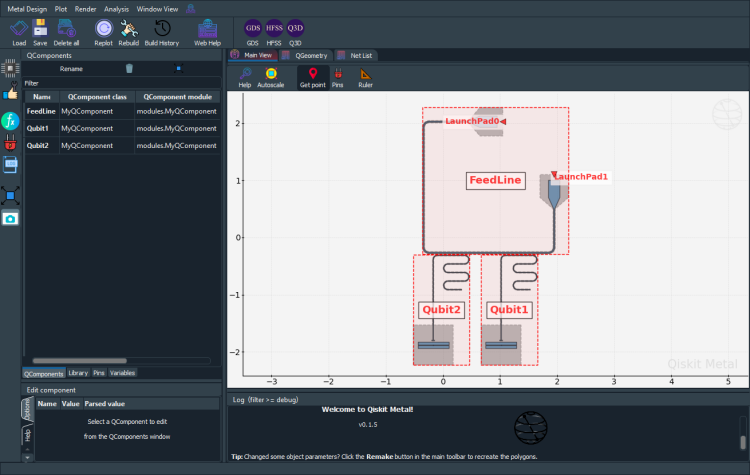

In [5]:
gui.rebuild()
#gui.autoscale()
#gui.edit_component(component)
gui.zoom_on_components(components)
gui.highlight_components(components)
gui.screenshot()

In [6]:
qcomps = design.components  # short handle (alias)
for i,qubit in enumerate(QubitList):
    qcomps[qubit].options['hfss_inductance'] = f'Lj{i}'
    qcomps[qubit].options['hfss_capacitance'] = f'Cj{i}'
gui.rebuild()  # line needed to propagate the updates from the qubit instance into the junction design table
gui.autoscale()

In [7]:
eig_qres = EPRanalysis(design, "hfss")
# example: update single setting
eig_qres.sim.setup.max_passes = 6
eig_qres.sim.setup.n_modes = 4
# example: update multiple settings
eig_qres.sim.setup_update(max_delta_f = 0.4, min_freq_ghz = 1.1)

eig_qres.sim.setup.vars = Dict(
    Lj0 = '11 nH', 
    Cj0 = '0 fF',
    Lj1 = '9 nH', 
    Cj1 = '0 fF',
    Lj2 = '13 nH', 
    Cj2 = '0 fF',
    Lj3 = '10 nH', 
    Cj3 = '0 fF',    
)


In [8]:
eig_qres.sim.setup

{'name': 'Setup',
 'reuse_selected_design': True,
 'reuse_setup': True,
 'min_freq_ghz': 1.1,
 'n_modes': 4,
 'max_delta_f': 0.4,
 'max_passes': 6,
 'min_passes': 1,
 'min_converged': 1,
 'pct_refinement': 30,
 'basis_order': 1,
 'vars': {'Lj0': '11 nH',
  'Cj0': '0 fF',
  'Lj1': '9 nH',
  'Cj1': '0 fF',
  'Lj2': '13 nH',
  'Cj2': '0 fF',
  'Lj3': '10 nH',
  'Cj3': '0 fF'}}

In [9]:
#eig_qres.sim.run(name="Qbit", components=components, open_terminations=[], box_plus_buffer = False)
#eig_qres.sim.plot_convergences()

In [10]:
#eig_qres.sim.plot_fields('main', eigenmode=2)

In [11]:
#eig_qres.sim.setup.n_modes = 10
#eig_qres.sim.run()

In [12]:
#eig_qres.sim.plot_fields('main', eigenmode=4)

## EPR Analysis

In [13]:
eig_qres.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [14]:
design.components
#design.qgeometry.get_component(name = "", table_name = 'junction')
#design.qgeometry.tables["junction"]

{1: name:    FeedLine
class:   MyQComponent          
options: 
  'pos_x'             : '0.0um',                      
  'pos_y'             : '0.0um',                      
  'orientation'       : '0.0',                        
  'chip'              : 'main',                       
  'layer'             : '1',                          
  'polygons_metal'    : [<POLYGON ((1.94 -0.168, 1.94 -0.169, 1.94 -0.17, 1.94 -0.17, 1.94 -0.171, 1....>],
  'polygons_pocket'   : [<POLYGON ((1.929 -0.168, 1.929 -0.169, 1.929 -0.169, 1.929 -0.17, 1.929 -0.1...>],
  'port_data'         : {
       'LaunchPad0'        : {
            'start'             : [1050.0, 1925.0],             
            'end'               : [1050.0, 2125.0],             
            'width'             : 200.0,                        
            'gap'               : 100.0,                        
                             },
       'LaunchPad1'        : {
            'start'             : [2050.0, 1100.0],             


In [15]:
design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,2,JJ,"LINESTRING (1.02000 -1.88900, 1.02000 -1.87300)",1,False,False,main,0.01,Lj0,Cj0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
1,3,JJ,"LINESTRING (-0.17000 -1.88900, -0.17000 -1.87300)",1,False,False,main,0.01,Lj1,Cj1,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [16]:
# for index in design.qgeometry.tables['junction'].index:
#     design.qgeometry.tables['junction'].loc[index,"hfss_inductance"] = f"Lj{index}"
#     design.qgeometry.tables['junction'].loc[index,"hfss_capacitance"] = f"Cj{index}"

design.qgeometry.tables['junction']

,component,name,geometry,layer,subtract,helper,chip,width,hfss_inductance,hfss_capacitance,...,hfss_mesh_kw_jj,q3d_inductance,q3d_capacitance,q3d_resistance,q3d_mesh_kw_jj,gds_cell_name,aedt_q3d_inductance,aedt_q3d_capacitance,aedt_hfss_inductance,aedt_hfss_capacitance
0,2,JJ,"LINESTRING (1.02000 -1.88900, 1.02000 -1.87300)",1,False,False,main,0.01,Lj0,Cj0,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0
1,3,JJ,"LINESTRING (-0.17000 -1.88900, -0.17000 -1.87300)",1,False,False,main,0.01,Lj1,Cj1,...,0.000007,10nH,0,0,0.000007,my_other_junction,1.000000e-08,0,1.000000e-08,0


In [17]:
eig_qres.setup

{'junctions': {'jj': {'Lj_variable': 'Lj',
   'Cj_variable': 'Cj',
   'rect': '',
   'line': ''}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj'}

In [19]:
for key in list(eig_qres.setup.junctions.keys()):
    del eig_qres.setup.junctions[key]
# eig_qres.setup.junctions.jj1 = Dict(rect='JJ_rect_Lj_Qubit1_jj', line='JJ_Lj_Q1_rect_jj_',
#                   Lj_variable='Lj1', Cj_variable='Cj1')
# eig_qres.setup.junctions.jj2 = Dict(rect='JJ_rect_Lj_Q2_rect_jj', line='JJ_Lj_Q2_rect_jj_',
#                   Lj_variable='Lj2', Cj_variable='Cj2')
# eig_qres.setup.sweep_variable = 'Lj1'
# eig_qres.setup
# #for jj in design.qgeometry.tables['junction']['name'].tolist():
#for index in design.qgeometry.tables['junction'].index:
for index, name in enumerate(QubitList):
    Lj = design.qgeometry.tables['junction'].loc[index,"hfss_inductance"]
    Cj = design.qgeometry.tables['junction'].loc[index,"hfss_capacitance"]
    eig_qres.setup.junctions[name] = Dict(rect=f'JJ_rect_Lj_{name}_JJ', line=f'JJ_Lj_{name}_JJ_',
                  Lj_variable=Lj, Cj_variable=Cj)
    print(name, name, Lj, Cj)

Qubit1 Qubit1 Lj0 Cj0
Qubit2 Qubit2 Lj1 Cj1


In [20]:
eig_qres.setup.sweep_variable = 'Lj1'
eig_qres.setup

{'junctions': {'Qubit1': {'rect': 'JJ_rect_Lj_Qubit1_JJ',
   'line': 'JJ_Lj_Qubit1_JJ_',
   'Lj_variable': 'Lj0',
   'Cj_variable': 'Cj0'},
  'Qubit2': {'rect': 'JJ_rect_Lj_Qubit2_JJ',
   'line': 'JJ_Lj_Qubit2_JJ_',
   'Lj_variable': 'Lj1',
   'Cj_variable': 'Cj1'}},
 'dissipatives': {'dielectrics_bulk': ['main']},
 'cos_trunc': 8,
 'fock_trunc': 7,
 'sweep_variable': 'Lj1'}

In [21]:
eig_qres.sim.setup.vars = Dict(
    Lj0 = '11 nH', 
    Cj0 = '0 fF',
    Lj1 = '9 nH', 
    Cj1 = '0 fF',
    Lj2 = '13 nH', 
    Cj2 = '0 fF',
    Lj3 = '10 nH', 
    Cj3 = '0 fF',    
)

In [22]:
eig_qres.sim.renderer.options['x_buffer_width_mm'] = 0.5
eig_qres.sim.renderer.options['y_buffer_width_mm'] = 0.5
eig_qres.sim.renderer.options

{'Lj': '10nH',
 'Cj': 0,
 '_Rj': 0,
 'max_mesh_length_jj': '7um',
 'max_mesh_length_port': '7um',
 'project_path': None,
 'project_name': None,
 'design_name': None,
 'x_buffer_width_mm': 0.5,
 'y_buffer_width_mm': 0.5,
 'wb_threshold': '400um',
 'wb_offset': '0um',
 'wb_size': 5,
 'plot_ansys_fields_options': {'name': 'NAME:Mag_E1',
  'UserSpecifyName': '0',
  'UserSpecifyFolder': '0',
  'QuantityName': 'Mag_E',
  'PlotFolder': 'E Field',
  'StreamlinePlot': 'False',
  'AdjacentSidePlot': 'False',
  'FullModelPlot': 'False',
  'IntrinsicVar': "Phase='0deg'",
  'PlotGeomInfo_0': '1',
  'PlotGeomInfo_1': 'Surface',
  'PlotGeomInfo_2': 'FacesList',
  'PlotGeomInfo_3': '1'}}

In [23]:
# port_list = [('FeedLine', 'LaunchPad0', 50),
#              ('FeedLine', 'LaunchPad1', 50)]
port_list = [('FeedLine', 'LaunchPad0'), ('FeedLine', 'LaunchPad1')]

eig_qres.sim.run(name="Qbit", 
                 components=components, 
                 open_terminations=port_list, 
                 box_plus_buffer = False)

INFO 03:03AM [connect_project]: Connecting to Ansys Desktop API...
INFO 03:03AM [load_ansys_project]: 	Opened Ansys App
INFO 03:03AM [load_ansys_project]: 	Opened Ansys Desktop v2023.2.0
INFO 03:03AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/HFSS/ymino/
	Project:   Project14
INFO 03:03AM [connect_design]: No active design found (or error getting active design).
INFO 03:03AM [connect]: 	 Connected to project "Project14". No design detected
INFO 03:03AM [connect_design]: 	Opened active design
	Design:    Qbit_hfss [Solution type: Eigenmode]
WARNING 03:03AM [connect_setup]: 	No design setup detected.
WARNING 03:03AM [connect_setup]: 	Creating eigenmode default setup.
INFO 03:03AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:05AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)
INFO 03:05AM [analyze]: Analyzing setup Setup
03:15AM 11s INFO [get_f_convergence]: Saved convergences to c:\Users\ymino\Documents\GitHub\qi

In [24]:
eig_qres.run_epr()

Design "Qbit_hfss" info:
	# eigenmodes    4
	# variations    1
Design "Qbit_hfss" info:
	# eigenmodes    4
	# variations    1


  options=pd.Series(get_instance_vars(self.options)),




        energy_elec_all       = 2.75082263634264e-24
        energy_elec_substrate = 2.62453284821525e-24
        EPR of substrate = 95.4%

        energy_mag    = 1.65174839178622e-26
        energy_mag % of energy_elec_all  = 0.6%
        

Variation 0  [1/1]


  Ljs = pd.Series({})

  Cjs = pd.Series({})

  _Om = pd.Series({})




  Mode 0 at 2.30 GHz   [1/4]
    Calculating ℰ_magnetic,ℰ_electric


...

###### Numerical diagonalization

Lj1,9
0,2261.40
1,2810.76
2,4435.85
3,5001.19


#### Kerr Non-linear coefficient table (MHz)

###### Numerical diagonalization

0         1         2         3
Lj1                                          
9   0  3.72e+01  1.18e-06  1.42e-06  1.19e-02
    1  1.18e-06  8.43e-06  8.95e-02  1.88e-07
    2  1.42e-06  8.95e-02  1.94e+02  5.65e-04
    3  1.19e-02  1.88e-07  5.65e-04  9.57e-07

In [ ]:
design_name= "Sweep_DrivenModal"
qcomp_render = [] # Means to render everything in qgeometry table.
open_terminations = []

box_plus_buffer = True

In [ ]:
# we use HFSS as rendere
hfss = em1.renderer
hfss.start()

In [ ]:
# Here we activate the design for a drivenmodal solution
hfss.activate_ansys_design("HangingResonator", 'hfss hybrid modal network')
setup_args = Dict(max_delta_s=0.001)
setup_args.name = 'Setup'
hfss.edit_drivenmodal_setup(setup_args)

In [ ]:
# set buffer
hfss.options['x_buffer_width_mm'] = 0.1
hfss.options['y_buffer_width_mm'] = 0.1

In [ ]:
# clean the design if needed
hfss.clean_active_design()

In [ ]:
# render the design
hfss.render_design(selection=[], 
                   open_pins=open_terminations, 
                   port_list=port_list, 
                   box_plus_buffer = box_plus_buffer)

In [ ]:
pinfo = hfss.pinfo
pinfo.design.set_variable('Lj', '10 nH')
pinfo.design.set_variable('Cj', '0 fF')

In [ ]:
hfss.add_sweep(setup_name="Setup", 
               name="Sweep", 
               start_ghz=7.0,
               stop_ghz=10.0,
               count=601,
               type="Interpolating")

In [ ]:
hfss.analyze_sweep('Sweep', 'Setup')

In [ ]:
%matplotlib inline
hfss.plot_params(['S11', 'S21'])

In [ ]:
hfss.disconnect_ansys()